In [2]:
# ============================================================
# NOTEBOOK 8 — SP-XGBOOST OPTUNA OPTIMISATION
# CELL 1 — IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import optuna
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
print("Libraries imported successfully.")
print("Optuna version:", optuna.__version__)

# ============================================================
# CELL 2 — DEFINE DIRECTORIES
# ============================================================
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "processed_data"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
PROCESSED_DIR = Path("../data/processed")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Project directory:", BASE_DIR)
print("Processed data:", PROCESSED_DIR)
print("Models:", MODELS_DIR)
print("Results:", RESULTS_DIR)

Libraries imported successfully.
Optuna version: 4.9.0
Project directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks
Processed data: ..\data\processed
Models: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models
Results: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results


In [3]:
# ============================================================
# CELL 3 — LOAD SHAP-SELECTED TRAINING DATA
# ============================================================

X_train_shap = pd.read_csv(
    PROCESSED_DIR / "X_train_shap.csv"
)

y_train_shap = pd.read_csv(
    PROCESSED_DIR / "y_train_shap.csv"
).squeeze()

print("=" * 70)
print("SHAP-SELECTED TRAINING DATA")
print("=" * 70)

print("X_train_shap shape:", X_train_shap.shape)
print("y_train_shap shape:", y_train_shap.shape)

print("\nTarget distribution:")
print(y_train_shap.value_counts().sort_index())

SHAP-SELECTED TRAINING DATA
X_train_shap shape: (658, 47)
y_train_shap shape: (658,)

Target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 4 — LOAD ORIGINAL UNTOUCHED TEST DATA
# ============================================================

X_test_clean = pd.read_csv(
    PROCESSED_DIR / "X_test_clean.csv"
)

y_test_clean = pd.read_csv(
    PROCESSED_DIR / "y_test_clean.csv"
).squeeze()

print("=" * 70)
print("ORIGINAL TEST DATA")
print("=" * 70)

print("X_test_clean shape:", X_test_clean.shape)
print("y_test_clean shape:", y_test_clean.shape)

print("\nTest target distribution:")
print(y_test_clean.value_counts().sort_index())

ORIGINAL TEST DATA
X_test_clean shape: (114, 58)
y_test_clean shape: (114,)

Test target distribution:
RISK_LABEL
0    83
1    31
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 5 — LOAD SHAP SELECTED FEATURES
# ============================================================

selected_features_df = pd.read_csv(
    RESULTS_DIR / "shap_selected_features.csv"
)

selected_features = (
    selected_features_df["Feature"]
    .tolist()
)

print("Number of SHAP-selected features:",
    len(selected_features))

print("\nSelected features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

Number of SHAP-selected features: 47

Selected features:
01. GPA_S1
02. Hopeless/unmotivated
03. Sleep_hrs
04. LAB_AVG
05. Programme prepares for career
06. Concentration in self-study
07. Adequate supervision
08. CA_AVG
09. Financial_diff
10. Employment_hrs
11. Can improve performance
12. Self-motivates
13. Sense of belonging
14. Manages time effectively
15. Early intervention provided
16. Persists when difficult
17. Peer study groups effective
18. Anxious about assessments
19. Takes rest breaks
20. Seeks help when stuck
21. Regular exercise
22. Participates in class
23. Considered break
24. Age_group
25. Understands content pre-exam
26. CLIN_AVG
27. Takes organised notes
28. Physical health affected
29. ATT_RATE
30. Lecturers approachable
31. Sets academic goals
32. Study_hrs_day
33. Completes readings
34. EXAM_AVG
35. Confident in clinical skills
36. Prepared for clinical assess
37. Rotations affect performance
38. Self_risk_percep
39. Schedule conflicts
40. Gender
41. Sleep difficu

In [9]:
# ============================================================
# CELL 6 — CREATE SHAP-SELECTED TEST MATRIX
# ============================================================

missing_test_features = [
    feature
    for feature in selected_features
    if feature not in X_test_clean.columns
]

if missing_test_features:
    print("Missing features:")
    print(missing_test_features)

    raise ValueError(
        "SHAP-selected features are missing from X_test."
    )

X_test_shap = X_test_clean[
    selected_features
].copy()

print("X_test_shap shape:", X_test_shap.shape)

X_test_shap shape: (114, 47)


In [11]:
# ============================================================
# CELL 7 — VERIFY DATA INTEGRITY
# ============================================================

print("=" * 70)
print("DATA INTEGRITY CHECK")
print("=" * 70)

print("Training observations:", X_train_shap.shape[0])
print("Training predictors:", X_train_shap.shape[1])

print("Test observations:", X_test_shap.shape[0])
print("Test predictors:", X_test_shap.shape[1])

print(
    "\nFeature order identical:",
    list(X_train_shap.columns) ==
    list(X_test_shap.columns)
)

print(
    "Training missing values:",
    X_train_shap.isnull().sum().sum()
)

print(
    "Test missing values:",
    X_test_shap.isnull().sum().sum()
)

print("\nTraining target distribution:")
print(y_train_shap.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test_clean.value_counts().sort_index())

DATA INTEGRITY CHECK
Training observations: 658
Training predictors: 47
Test observations: 114
Test predictors: 47

Feature order identical: True
Training missing values: 0
Test missing values: 0

Training target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

Test target distribution:
RISK_LABEL
0    83
1    31
Name: count, dtype: int64


In [12]:
# ============================================================
# CELL 8 — INTERNAL TRAIN/VALIDATION SPLIT
# ============================================================

X_opt_train, X_opt_valid, y_opt_train, y_opt_valid = train_test_split(
    X_train_shap,
    y_train_shap,
    test_size=0.20,
    stratify=y_train_shap,
    random_state=42
)

print("=" * 70)
print("INTERNAL OPTUNA TRAIN/VALIDATION SPLIT")
print("=" * 70)

print("Optimization training shape:",
    X_opt_train.shape)

print("Optimization validation shape:",
    X_opt_valid.shape)

print("\nOptimization training target:")
print(y_opt_train.value_counts().sort_index())

print("\nOptimization validation target:")
print(y_opt_valid.value_counts().sort_index())

INTERNAL OPTUNA TRAIN/VALIDATION SPLIT
Optimization training shape: (526, 47)
Optimization validation shape: (132, 47)

Optimization training target:
RISK_LABEL
0    263
1    263
Name: count, dtype: int64

Optimization validation target:
RISK_LABEL
0    66
1    66
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 9 — DEFINE OPTUNA OBJECTIVE FUNCTION
# ============================================================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500,
            step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30,
            log=True
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.60,
            1.00
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0.0,
            5.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10.0,
            log=True
        ),

        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_opt_train,
        y_opt_train
    )

    validation_probability = model.predict_proba(
        X_opt_valid
    )[:, 1]

    validation_auc = roc_auc_score(
        y_opt_valid,
        validation_probability
    )

    return validation_auc

In [ ]:
# ============================================================
# CELL 10 — CREATE OPTUNA STUDY
# ============================================================

study = optuna.create_study(
    direction="maximize",
    study_name="SP_XGBoost"
)

print("Optuna study created successfully.")
print("Optimization objective: maximize ROC-AUC")

[I 2026-07-29 01:14:27,690] A new study created in memory with name: SP_XGBoost


Optuna study created successfully.
Optimization objective: maximize ROC-AUC


In [18]:
# ============================================================
# CELL 11 — RUN OPTUNA OPTIMISATION
# ============================================================

print("=" * 70)
print("STARTING OPTUNA OPTIMISATION")
print("=" * 70)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print("\n✓ Optuna optimisation completed.")

STARTING OPTUNA OPTIMISATION


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-29 01:16:23,728] Trial 150 finished with value: 0.8971533516988062 and parameters: {'n_estimators': 450, 'max_depth': 8, 'learning_rate': 0.031637350709910035, 'min_child_weight': 1, 'subsample': 0.7414529577344116, 'colsample_bytree': 0.8209469835805563, 'gamma': 2.9764636820904715, 'reg_alpha': 0.5877277545474869, 'reg_lambda': 2.0850958082877514e-08}. Best is trial 139 with value: 0.9410009182736455.
[I 2026-07-29 01:16:24,229] Trial 151 finished with value: 0.9306703397612489 and parameters: {'n_estimators': 450, 'max_depth': 8, 'learning_rate': 0.03529443628792525, 'min_child_weight': 1, 'subsample': 0.7887767704210014, 'colsample_bytree': 0.8425681834755694, 'gamma': 0.23371479714197596, 'reg_alpha': 0.0759558204093665, 'reg_lambda': 1.3423560566851854e-07}. Best is trial 139 with value: 0.9410009182736455.
[I 2026-07-29 01:16:24,591] Trial 152 finished with value: 0.9338842975206613 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.0300749817739

In [19]:
# ============================================================
# CELL 12 — BEST OPTUNA RESULT
# ============================================================

print("=" * 70)
print("BEST OPTUNA RESULT")
print("=" * 70)

print(
    f"Best validation ROC-AUC: "
    f"{study.best_value:.4f}"
)

print("\nBest hyperparameters:")

for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

BEST OPTUNA RESULT
Best validation ROC-AUC: 0.9410

Best hyperparameters:
n_estimators: 450
max_depth: 8
learning_rate: 0.031421011007290764
min_child_weight: 1
subsample: 0.7835513171100621
colsample_bytree: 0.8432983574665387
gamma: 0.0018324957139797468
reg_alpha: 0.09018439286102096
reg_lambda: 7.110933538908287e-08


In [20]:
# ============================================================
# CELL 13 — OPTUNA TRIAL RESULTS
# ============================================================

optuna_results = study.trials_dataframe()

print("Number of trials:",
    len(optuna_results))

display(
    optuna_results[
        [
            "number",
            "value",
            "state"
        ]
    ].sort_values(
        by="value",
        ascending=False
    ).head(10)
)

Number of trials: 200


,number,value,state
139,139,0.941001,COMPLETE
111,111,0.940312,COMPLETE
132,132,0.939164,COMPLETE
22,22,0.938705,COMPLETE
194,194,0.938476,COMPLETE
120,120,0.937787,COMPLETE
181,181,0.937787,COMPLETE
160,160,0.937787,COMPLETE
186,186,0.937787,COMPLETE
197,197,0.937098,COMPLETE


C:\Users\HP\AppData\Local\Temp\ipykernel_22120\1133101584.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(


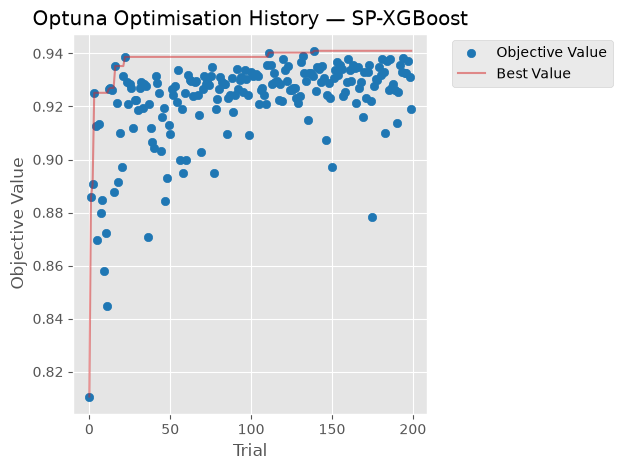

In [21]:
# ============================================================
# CELL 14 — OPTUNA OPTIMISATION HISTORY
# ============================================================

fig = optuna.visualization.matplotlib.plot_optimization_history(
    study
)

plt.title(
    "Optuna Optimisation History — SP-XGBoost"
)

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_22120\513430907.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(


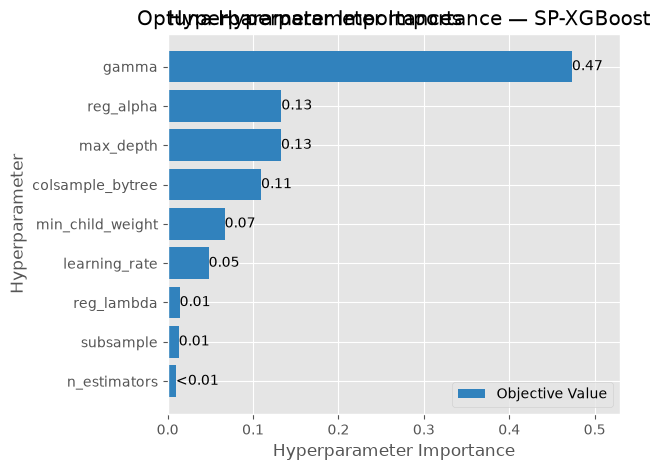

In [22]:
# ============================================================
# CELL 15 — OPTUNA PARAMETER IMPORTANCE
# ============================================================

fig = optuna.visualization.matplotlib.plot_param_importances(
    study
)

plt.title(
    "Optuna Hyperparameter Importance — SP-XGBoost"
)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 16 — SAVE OPTUNA TRIAL RESULTS
# ============================================================

optuna_results_path = (
    RESULTS_DIR / "SP_XGBoost_optuna_trials.csv"
)

optuna_results.to_csv(
    optuna_results_path,
    index=False
)

print("Optuna trial results saved successfully.")
print("Saved to:", optuna_results_path)

Optuna trial results saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\SP_XGBoost_optuna_trials.csv


In [25]:
# ============================================================
# CELL 17 — SAVE BEST HYPERPARAMETERS
# ============================================================

best_params_df = pd.DataFrame(
    [
        study.best_params
    ]
)

best_params_df["best_validation_ROC_AUC"] = (
    study.best_value
)

best_params_path = (
    RESULTS_DIR / "SP_XGBoost_best_parameters.csv"
)

best_params_df.to_csv(
    best_params_path,
    index=False
)

print("Best hyperparameters saved successfully.")
print("Saved to:", best_params_path)

display(best_params_df)

Best hyperparameters saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\SP_XGBoost_best_parameters.csv


,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,best_validation_ROC_AUC
0,450,8,0.031421,1,0.783551,0.843298,0.001832,0.090184,7.110934e-08,0.941001


In [26]:
# ============================================================
# CELL 18 — TRAIN FINAL SP-XGBOOST
# ============================================================

best_params = study.best_params.copy()

best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1
})

sp_xgb = XGBClassifier(
    **best_params
)

print("=" * 70)
print("TRAINING FINAL SP-XGBOOST")
print("=" * 70)

print("Training observations:", X_train_shap.shape[0])
print("Training predictors:", X_train_shap.shape[1])

sp_xgb.fit(
    X_train_shap,
    y_train_shap
)

print("\n✓ Final SP-XGBoost training completed.")

TRAINING FINAL SP-XGBOOST
Training observations: 658
Training predictors: 47

✓ Final SP-XGBoost training completed.


In [27]:
# ============================================================
# CELL 19 — FINAL TEST PREDICTIONS
# ============================================================

y_pred_sp = sp_xgb.predict(
    X_test_shap
)

y_prob_sp = sp_xgb.predict_proba(
    X_test_shap
)[:, 1]

print("Final SP-XGBoost test predictions generated.")

print("\nPrediction distribution:")
print(
    pd.Series(y_pred_sp)
    .value_counts()
    .sort_index()
)

Final SP-XGBoost test predictions generated.

Prediction distribution:
0    89
1    25
Name: count, dtype: int64


In [28]:
# ============================================================
# CELL 20 — FINAL SP-XGBOOST PERFORMANCE
# ============================================================

accuracy_sp = accuracy_score(
    y_test_clean,
    y_pred_sp
)

precision_sp = precision_score(
    y_test_clean,
    y_pred_sp,
    zero_division=0
)

recall_sp = recall_score(
    y_test_clean,
    y_pred_sp,
    zero_division=0
)

f1_sp = f1_score(
    y_test_clean,
    y_pred_sp,
    zero_division=0
)

auc_sp = roc_auc_score(
    y_test_clean,
    y_prob_sp
)

print("=" * 70)
print("FINAL SP-XGBOOST PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy_sp:.4f}")
print(f"Precision: {precision_sp:.4f}")
print(f"Recall   : {recall_sp:.4f}")
print(f"F1-score : {f1_sp:.4f}")
print(f"ROC-AUC  : {auc_sp:.4f}")

FINAL SP-XGBOOST PERFORMANCE
Accuracy : 0.7018
Precision: 0.4400
Recall   : 0.3548
F1-score : 0.3929
ROC-AUC  : 0.6319


In [29]:
# ============================================================
# CELL 21 — SP-XGBOOST CLASSIFICATION REPORT
# ============================================================

print("=" * 70)
print("SP-XGBOOST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test_clean,
        y_pred_sp,
        target_names=[
            "Not At-Risk",
            "At-Risk"
        ],
        zero_division=0
    )
)

SP-XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not At-Risk       0.78      0.83      0.80        83
     At-Risk       0.44      0.35      0.39        31

    accuracy                           0.70       114
   macro avg       0.61      0.59      0.60       114
weighted avg       0.68      0.70      0.69       114



SP-XGBoost Confusion Matrix:
[[69 14]
 [20 11]]


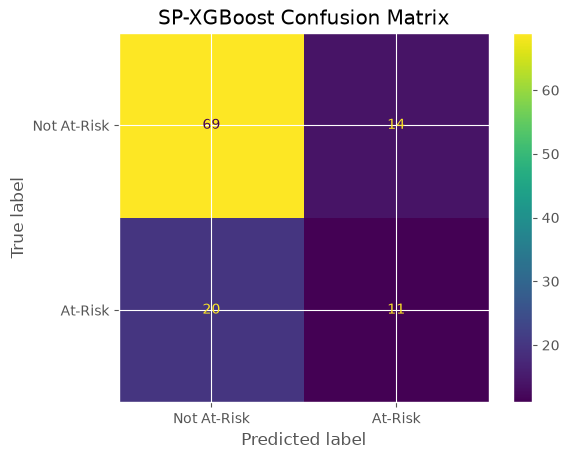

In [30]:
# ============================================================
# CELL 22 — SP-XGBOOST CONFUSION MATRIX
# ============================================================

cm_sp = confusion_matrix(
    y_test_clean,
    y_pred_sp
)

print("SP-XGBoost Confusion Matrix:")
print(cm_sp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sp,
    display_labels=[
        "Not At-Risk",
        "At-Risk"
    ]
)

disp.plot()

plt.title(
    "SP-XGBoost Confusion Matrix"
)

plt.show()

In [31]:
# ============================================================
# CELL 23 — COMPLETE MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "S-XGBoost",
        "SP-XGBoost"
    ],

    "Features": [
        58,
        47,
        47
    ],

    "Accuracy": [
        0.710526,
        0.710526,
        accuracy_sp
    ],

    "Precision": [
        0.458333,
        0.461538,
        precision_sp
    ],

    "Recall": [
        0.354839,
        0.387097,
        recall_sp
    ],

    "F1": [
        0.400000,
        0.421053,
        f1_sp
    ],

    "ROC_AUC": [
        0.650214,
        0.642105,
        auc_sp
    ]
})

print("=" * 80)
print("COMPLETE MODEL COMPARISON")
print("=" * 80)

display(final_comparison)

COMPLETE MODEL COMPARISON


,Model,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline XGBoost,58,0.710526,0.458333,0.354839,0.400000,0.650214
1,S-XGBoost,47,0.710526,0.461538,0.387097,0.421053,0.642105
2,SP-XGBoost,47,0.701754,0.440000,0.354839,0.392857,0.631947


In [32]:
# ============================================================
# CELL 24 — SP-XGBOOST IMPROVEMENT OVER BASELINE
# ============================================================

baseline_auc = 0.650214
baseline_f1 = 0.400000
baseline_recall = 0.354839

print("=" * 70)
print("SP-XGBOOST IMPROVEMENT OVER BASELINE")
print("=" * 70)

print(
    f"ROC-AUC change: "
    f"{auc_sp - baseline_auc:+.4f}"
)

print(
    f"F1 change: "
    f"{f1_sp - baseline_f1:+.4f}"
)

print(
    f"Recall change: "
    f"{recall_sp - baseline_recall:+.4f}"
)

SP-XGBOOST IMPROVEMENT OVER BASELINE
ROC-AUC change: -0.0183
F1 change: -0.0071
Recall change: -0.0000


In [33]:
# ============================================================
# CELL 25 — SAVE FINAL SP-XGBOOST MODEL
# ============================================================

sp_model_path = (
    MODELS_DIR / "SP_XGBoost.pkl"
)

joblib.dump(
    sp_xgb,
    sp_model_path
)

print("Final SP-XGBoost model saved successfully.")
print("Saved to:", sp_model_path)

Final SP-XGBoost model saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost.pkl


In [34]:
# ============================================================
# CELL 26 — SAVE FINAL RESULTS
# ============================================================

sp_results = pd.DataFrame({
    "Model": ["SP-XGBoost"],
    "Features": [len(selected_features)],
    "Accuracy": [accuracy_sp],
    "Precision": [precision_sp],
    "Recall": [recall_sp],
    "F1": [f1_sp],
    "ROC_AUC": [auc_sp],
    "Best_Validation_ROC_AUC": [study.best_value]
})

sp_results_path = (
    RESULTS_DIR / "SP_XGBoost_results.csv"
)

sp_results.to_csv(
    sp_results_path,
    index=False
)

print("SP-XGBoost results saved successfully.")
print("Saved to:", sp_results_path)

display(sp_results)

SP-XGBoost results saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\SP_XGBoost_results.csv


,Model,Features,Accuracy,Precision,Recall,F1,ROC_AUC,Best_Validation_ROC_AUC
0,SP-XGBoost,47,0.701754,0.44,0.354839,0.392857,0.631947,0.941001


In [35]:
# ============================================================
# CELL 27 — NOTEBOOK 8 FINAL SUMMARY
# ============================================================

print("=" * 80)
print("NOTEBOOK 8 — SP-XGBOOST FINAL SUMMARY")
print("=" * 80)

print("SHAP-selected predictors:", len(selected_features))
print("Optuna trials:", len(study.trials))

print(
    f"\nBest internal validation ROC-AUC: "
    f"{study.best_value:.4f}"
)

print("\nFINAL TEST PERFORMANCE")
print("-" * 50)

print(f"Accuracy : {accuracy_sp:.4f}")
print(f"Precision: {precision_sp:.4f}")
print(f"Recall   : {recall_sp:.4f}")
print(f"F1-score : {f1_sp:.4f}")
print(f"ROC-AUC  : {auc_sp:.4f}")

print("\n✓ Notebook 8 completed.")

NOTEBOOK 8 — SP-XGBOOST FINAL SUMMARY
SHAP-selected predictors: 47
Optuna trials: 200

Best internal validation ROC-AUC: 0.9410

FINAL TEST PERFORMANCE
--------------------------------------------------
Accuracy : 0.7018
Precision: 0.4400
Recall   : 0.3548
F1-score : 0.3929
ROC-AUC  : 0.6319

✓ Notebook 8 completed.
